# Lithium perovskite hydrides: atomistic structures and NeqSim gas equilibrium

This executed study connects **ASE** crystal structures, a small **PySCF** molecular DFT
calculation, and **NeqSim** hydrogen fugacity to screen solid-state storage. It is a companion
to [equinor/neqsim#4036](https://github.com/equinor/neqsim/issues/4036) and
[the native NeqSim screening implementation](https://github.com/equinor/neqsim/pull/4042).

**Research source.** Geldasa and Dejene, *Journal of Molecular Modeling* 32, 288 (2026),
[DOI:10.1007/s00894-026-06861-x](https://doi.org/10.1007/s00894-026-06861-x).
Their reported cubic lattice constants and Table 5 storage metrics are literature inputs,
not measurements reproduced by this notebook. The PySCF H₂ calculation is a separate
molecular demonstration; its energy is **not** combined with the paper's bulk DFT energies.

**Learning outcomes.** Reconstruct theoretical gravimetric and crystal-volume capacities;
trace a source-built NeqSim class to an immutable commit; compute hydrogen fugacity with SRK;
solve a pressure-dependent desorption Gibbs balance; identify material-data gaps.

In [1]:
import importlib.metadata as metadata
import os
from pathlib import Path
import subprocess
import sys

required = {"ase": "3.26.0", "neqsim": "3.20.0", "pyscf": "2.11.0"}
missing = []
for name, version in required.items():
    try:
        installed = metadata.version(name)
    except metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        missing.append(name)
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"]
        + [f"{name}=={version}" for name, version in required.items()]
    )
print("Python:", sys.version.split()[0])
for name in required:
    print(f"{name}: {metadata.version(name)}")

Python: 3.12.14
ase: 3.26.0
neqsim: 3.20.0
pyscf: 2.11.0


## 1. Pin and build the NeqSim physics implementation

The PyPI package provides the JPype bridge. This cell builds the **actual NeqSim source** at
the immutable implementation commit, then checks that the loaded Java class came from its
shaded JAR. In a clean Colab runtime, the source is cloned and built with Maven. For local
validation, `NEQSIM_SOURCE_ROOT` can point at the same checked-out commit and built JAR.
The SRK gas EOS is therefore the same build as the new hydride utility.

In [2]:
import hashlib
import jpype

NEQSIM_SOURCE_REF = "809c7b21f6d7985df1b5cc896c7e2c3a285510fe"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/tmp/neqsim_4036_source"))
if not (source_root / ".git").exists():
    subprocess.check_call(
        ["git", "clone", "--depth", "1", "--filter=blob:none", "--branch",
         "feat/4036-hydride-storage-screening", "https://github.com/equinor/neqsim.git",
         str(source_root)]
    )
resolved_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
).strip()
assert resolved_commit == NEQSIM_SOURCE_REF, (resolved_commit, NEQSIM_SOURCE_REF)

jar_candidates = list((source_root / "target").glob("neqsim-*.jar"))
jar_candidates = [path for path in jar_candidates
                  if "sources" not in path.name and "javadoc" not in path.name]
if not jar_candidates:
    subprocess.check_call([str(source_root / "mvnw"), "-q", "-DskipTests",
                           "-Dmaven.javadoc.skip=true", "package"],
                          cwd=source_root)
    jar_candidates = [path for path in (source_root / "target").glob("neqsim-*.jar")
                      if "sources" not in path.name and "javadoc" not in path.name]
assert len(jar_candidates) == 1, jar_candidates
source_jar = jar_candidates[0].resolve()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
jpype.addClassPath(str(source_jar))
from neqsim.neqsimpython import init_jvm
init_jvm()
from neqsim import jneqsim

Hydride = jpype.JClass("neqsim.thermo.util.hydrogen.HydrideStorageScreening")
class_location = str(Hydride.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.name in class_location, class_location
print("NeqSim source commit:", resolved_commit)
print("Source JAR SHA-256:", hashlib.sha256(source_jar.read_bytes()).hexdigest())
print("Loaded hydride class from:", source_jar.name)

NeqSim source commit: 809c7b21f6d7985df1b5cc896c7e2c3a285510fe
Source JAR SHA-256: d0b19dbc024b9e5691da0ba5cc814203618b4319e278cb94d28e5940c99731aa
Loaded hydride class from: neqsim-3.22.0.jar


## 2. Build the reported crystal cells with ASE

Each ideal cubic $\mathrm{LiXH_3}$ unit cell has one Li, one X and three H atoms.
The lattice constants below come from Table 1 of the paper. ASE constructs coordinates
and atomic masses. **These are supplied structures, not relaxed DFT predictions.**

$$C_{wt}=100\frac{3M_H}{M_{Li}+M_X+3M_H}$$

$$\rho_{H_2}=\frac{3M_H}{N_Aa^3}$$

Here $M$ is molar mass in g/mol, $a$ is the lattice constant (converted from Å so
$a^3$ is in litres per cell), and $\rho_{H_2}$ is g H₂/L of ideal crystal.

In [3]:
import numpy as np
import pandas as pd
from ase import Atoms
from ase.io import write
from IPython.display import display

paper = {
    "B":  {"a_A": 3.087, "wt_pct": 14.56, "g_L": 170.6, "T_K": 561.1},
    "Cu": {"a_A": 3.369, "wt_pct": 4.11, "g_L": 131.3, "T_K": 457.7},
    "Mg": {"a_A": 3.756, "wt_pct": 8.82, "g_L": 94.8, "T_K": 509.4},
    "Si": {"a_A": 3.691, "wt_pct": 7.95, "g_L": 99.9, "T_K": 465.1},
}
positions = [(0, 0, 0), (0.5, 0.5, 0.5),
             (0.5, 0.5, 0), (0.5, 0, 0.5), (0, 0.5, 0.5)]
structures = {}
rows = []
for element, reference in paper.items():
    cell = Atoms(["Li", element, "H", "H", "H"], scaled_positions=positions,
                 cell=[reference["a_A"]] * 3, pbc=True)
    structures[element] = cell
    host_mass = float(sum(cell.get_masses()[:2]))
    wt_pct = Hydride.gravimetricCapacityPercent(host_mass, 3)
    g_per_litre = Hydride.volumetricHydrogenDensityGPerL(3, 1, cell.get_volume())
    rows.append({"material": f"Li{element}H3", "cell_A3": cell.get_volume(),
                 "capacity_wt_pct": wt_pct, "paper_wt_pct": reference["wt_pct"],
                 "crystal_g_H2_L": g_per_litre, "paper_g_H2_L": reference["g_L"]})
capacities = pd.DataFrame(rows).set_index("material")
display(capacities.round(2))
assert np.max(abs(capacities.capacity_wt_pct - capacities.paper_wt_pct)) < 0.06
assert np.max(abs(capacities.crystal_g_H2_L - capacities.paper_g_H2_L)) < 0.7

write("LiCuH3_reported_cell.cif", structures["Cu"])
print("ASE CIF exported: LiCuH3_reported_cell.cif")
print("LiCuH3 atoms:", structures["Cu"].get_chemical_symbols())
print("Capacity and crystal-density comparisons passed (rounding tolerance).")

,cell_A3,capacity_wt_pct,paper_wt_pct,crystal_g_H2_L,paper_g_H2_L
material,,,,,
LiBH3,29.42,14.56,14.56,170.68,170.6
LiCuH3,38.24,4.11,4.11,131.31,131.3
LiMgH3,52.99,8.82,8.82,94.76,94.8
LiSiH3,50.28,7.95,7.95,99.86,99.9


ASE CIF exported: LiCuH3_reported_cell.cif
LiCuH3 atoms: ['Li', 'Cu', 'H', 'H', 'H']
Capacity and crystal-density comparisons passed (rounding tolerance).


## 3. Molecular DFT reference: isolated H₂

PySCF is open-source electronic-structure software. The short PBE/STO-3G scan below
shows an H₂ bond energy minimum. A consistent hydride formation calculation would
require bulk hydride and decomposition-product energies, zero-point corrections,
phonons and thermal contributions at the **same** electronic-structure level.
This molecular result is never inserted into the paper's reaction enthalpy.

In [4]:
from pyscf import dft, gto, lib

# Some sandboxed kernels hide /proc/<pid>/statm; PySCF uses it only to size memory.
try:
    lib.current_memory()
except FileNotFoundError:
    lib.current_memory = lambda: (0.0, 0.0)

bond_lengths_A = np.array([0.62, 0.68, 0.74, 0.80, 0.88])
h2_energies_hartree = []
for length_A in bond_lengths_A:
    molecule = gto.M(atom=f"H 0 0 0; H 0 0 {length_A}", basis="sto-3g",
                     spin=0, charge=0, verbose=0)
    calculation = dft.RKS(molecule)
    calculation.xc = "pbe"
    calculation.grids.level = 1
    calculation.verbose = 0
    h2_energies_hartree.append(calculation.kernel())
h2_energies_hartree = np.asarray(h2_energies_hartree)
minimum_index = int(np.argmin(h2_energies_hartree))
display(pd.DataFrame({"bond_A": bond_lengths_A,
                      "PBE_STO3G_energy_Hartree": h2_energies_hartree}).round(6))
print("Lowest sampled H2 energy at", bond_lengths_A[minimum_index], "Å")
assert 0 < minimum_index < len(bond_lengths_A) - 1

,bond_A,PBE_STO3G_energy_Hartree
0,0.62,-1.137725
1,0.68,-1.149260
2,0.74,-1.152074
3,0.80,-1.148906
4,0.88,-1.138562


Lowest sampled H2 energy at 0.74 Å


## 4. NeqSim gas fugacity and pressure-dependent equilibrium

For desorption to specified solid products, take $\Delta H_{des}$ and
$\Delta S_{des}$ **per mole of H₂**. At unit solid activities:

$$\Delta G_{des}=\Delta H_{des}-T\Delta S_{des}+RT\ln(f_{H_2}/1\,\mathrm{bara})$$

The gas fugacity $f_{H_2}=\phi_{H_2}y_{H_2}P$ is obtained from NeqSim SRK at
each trial temperature, where $P$ is absolute bar. The paper assumes
$\Delta S_{des}=130.7$ J/(mol H₂ K). We infer $\Delta H_{des}$ from its Table 5
1-bar temperatures, so the ambient-pressure results are **anchored**, not
independent enthalpy predictions. Its formation energies in eV/atom cannot be
substituted for this reaction enthalpy.

In [5]:
from scipy.optimize import brentq

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
entropy_j_mol_k = 130.7
pressures_bara = [1.0, 10.0, 50.0]

def hydrogen_fugacity(temperature_k, pressure_bara):
    fluid = SystemSrkEos(float(temperature_k), float(pressure_bara))
    fluid.addComponent("hydrogen", 1.0)
    fluid.setMixingRule("classic")
    ThermodynamicOperations(fluid).TPflash()
    component = fluid.getPhase("gas").getComponent("hydrogen")
    phi = float(component.getFugacityCoefficient())
    gas_mole_fraction = float(component.getx())
    fugacity_bara = phi * gas_mole_fraction * float(fluid.getPressure())
    assert phi > 0.0 and 0.0 < gas_mole_fraction <= 1.0
    return fugacity_bara, phi

gas_rows = []
for pressure in pressures_bara:
    fugacity, phi = hydrogen_fugacity(457.7, pressure)
    gas_rows.append({"pressure_bara": pressure, "phi_H2": phi,
                     "f_H2_bara": fugacity})
display(pd.DataFrame(gas_rows).round(5))

equilibrium_rows = []
for element, reference in paper.items():
    enthalpy_j_mol = reference["T_K"] * entropy_j_mol_k
    for pressure in pressures_bara:
        def gibbs(temperature_k):
            fugacity, _ = hydrogen_fugacity(temperature_k, pressure)
            return float(Hydride.desorptionGibbsEnergyJPerMolH2(
                temperature_k, fugacity, enthalpy_j_mol, entropy_j_mol_k))

        equilibrium_k = brentq(gibbs, 250.0, 850.0, xtol=1.0e-6)
        fugacity, phi = hydrogen_fugacity(equilibrium_k, pressure)
        assert abs(gibbs(equilibrium_k)) < 1.0e-3
        equilibrium_rows.append({"material": f"Li{element}H3", "pressure_bara": pressure,
                                 "fugacity_bara": fugacity, "equilibrium_K": equilibrium_k,
                                 "paper_T_at_1bar_K": reference["T_K"]})
equilibria = pd.DataFrame(equilibrium_rows)
display(equilibria.pivot(index="material", columns="pressure_bara",
                         values="equilibrium_K").round(1))
for material, group in equilibria.groupby("material"):
    assert group.sort_values("pressure_bara").equilibrium_K.is_monotonic_increasing
print("All 12 Gibbs residuals are below 1e-3 J/mol H2; pressure trend passed.")

,pressure_bara,phi_H2,f_H2_bara
0,1.0,1.00041,1.00041
1,10.0,1.00410,10.04103
2,50.0,1.02079,51.03929


pressure_bara,1.0,10.0,50.0
material,,,
LiBH3,561.1,657.5,747.9
LiCuH3,457.7,536.4,610.2
LiMgH3,509.4,597.0,679.0
LiSiH3,465.1,545.1,620.1


All 12 Gibbs residuals are below 1e-3 J/mol H2; pressure trend passed.


## 5. Inspect the material-to-process handoff

The left panel shows ideal crystal storage density against formula-unit mass
fraction. The right panel shows how increasing NeqSim hydrogen fugacity shifts
the *assumed* solid reaction equilibrium. These are upper-bound capacity and
conditional thermodynamic curves, not measured reversible working capacities.

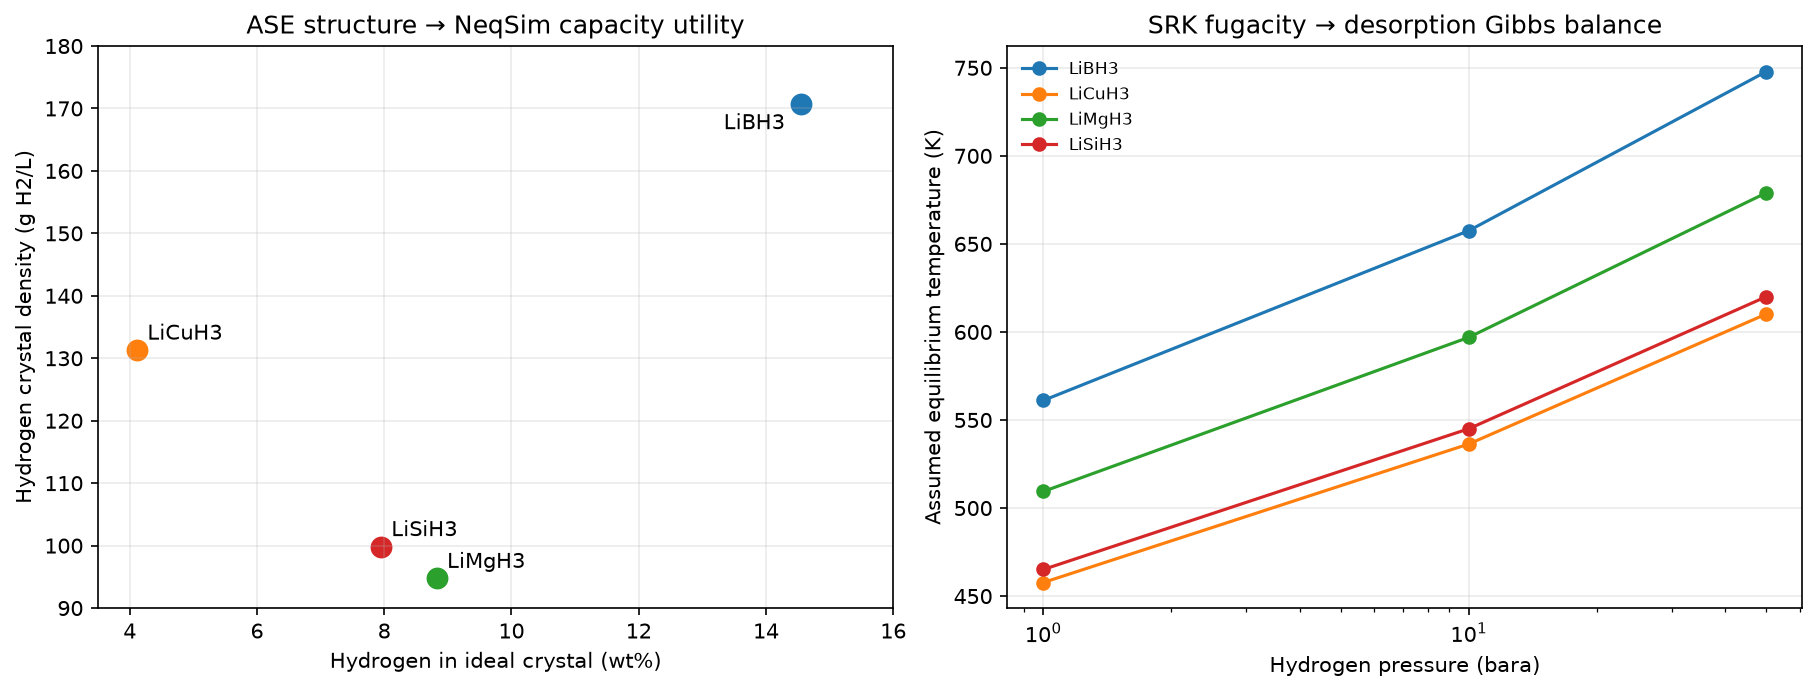

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for material, row in capacities.iterrows():
    axes[0].scatter(row.capacity_wt_pct, row.crystal_g_H2_L, s=90)
    label_offset = (-8, -12) if material == "LiBH3" else (5, 5)
    alignment = "right" if material == "LiBH3" else "left"
    axes[0].annotate(material, (row.capacity_wt_pct, row.crystal_g_H2_L),
                     xytext=label_offset, textcoords="offset points", ha=alignment)
axes[0].set(xlabel="Hydrogen in ideal crystal (wt%)",
            ylabel="Hydrogen crystal density (g H2/L)",
            title="ASE structure → NeqSim capacity utility")
axes[0].set_xlim(3.5, 16.0)
axes[0].set_ylim(90.0, 180.0)
axes[0].grid(alpha=0.25)

for material, group in equilibria.groupby("material"):
    axes[1].plot(group.pressure_bara, group.equilibrium_K, marker="o", label=material)
axes[1].set(xscale="log", xlabel="Hydrogen pressure (bara)",
            ylabel="Assumed equilibrium temperature (K)",
            title="SRK fugacity → desorption Gibbs balance")
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(alpha=0.25)
plt.show()

## 6. Engineering interpretation and validity

- **Reproduced:** Formula-unit capacity and cell-density arithmetic agrees with
  the paper's values within rounding. The pressure-dependent root satisfies
  the stated Gibbs equation and rises monotonically with hydrogen pressure.
- **Source inconsistency:** The paper abstract states 382.7 K for LiCuH₃, whereas
  its results text and Table 5 report 457.7 K. This notebook uses Table 5 and
  does not resolve that discrepancy. LiSiH₃ is reported dynamically unstable.
- **Unverified material boundary:** There are no experimental measurements for
  these proposed compounds in the cited paper. Product phases, full reaction
  free energies, reversibility, kinetics, diffusion, hysteresis, heat transfer,
  cycling, bed porosity and vessel mass are unknown here. A negative formation
  energy versus elements does not establish stability against other compounds.
- **Next research step:** Run consistent periodic DFT and phonon calculations
  (for example Quantum ESPRESSO) for the hydride and all competing products,
  establish reaction $\Delta H(T)$/$\Delta S(T)$ with uncertainty, then
  replace the anchored reference parameters and compare with measured PCT data.

The notebook evaluates research candidates and process boundary sensitivity;
it does not rank deployable hydrogen storage systems or provide a design basis.